In [1]:
import pandas as pd
import numpy as np

# NLP
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Clustering
from sklearn.cluster import KMeans

# Visualization
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [2]:
df = pd.read_csv("ClimbingPorn.csv")

df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,...,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.372000e+09,242,i.imgur.com,1gwshx,Gear testing at the office [1280 X 1280],randoh12,265,23,11,http://www.reddit.com/r/ClimbingPorn/comments/...,...,False,http://c.thumbs.redditmedia.com/x-lT0jMgcT2yBj...,t5_2so99,False,NaN,NaN,False,t3_1gwshx,http://i.imgur.com/Vx63A3D.jpg?1,NaN
1,1.346947e+09,213,i.imgur.com,zgcrn,Abandoned steel plant? Turn it into a climbin...,drednaught,216,3,13,http://www.reddit.com/r/ClimbingPorn/comments/...,...,False,http://a.thumbs.redditmedia.com/bMUDVeA-xQvn_G...,t5_2so99,False,NaN,NaN,False,t3_zgcrn,http://i.imgur.com/GB9Vh.jpg,NaN
2,1.335726e+09,206,i.imgur.com,sygq9,"One False Move... The Eiger Summit Ridge, Swit...",Optimistic_Corndog,212,6,14,http://www.reddit.com/r/ClimbingPorn/comments/...,...,False,http://a.thumbs.redditmedia.com/7ZMN7U_kT4xR8S...,t5_2so99,False,NaN,NaN,False,t3_sygq9,http://i.imgur.com/mooCZ.jpg,NaN
3,1.346689e+09,204,i.imgur.com,za9x8,Kevin Jorgeson (left) and Tommy Caldwell live ...,drednaught,205,1,12,http://www.reddit.com/r/ClimbingPorn/comments/...,...,False,http://b.thumbs.redditmedia.com/1vjbXr3IwO6Pu7...,t5_2so99,False,NaN,NaN,False,t3_za9x8,http://i.imgur.com/w9QzH.jpg,NaN
4,1.352986e+09,157,i.dailymail.co.uk,138kxj,Dan Arkle light painting while climbing at Sta...,soupyhands,162,5,9,http://www.reddit.com/r/ClimbingPorn/comments/...,...,False,http://e.thumbs.redditmedia.com/YKf_Rm1YVb030c...,t5_2so99,False,NaN,Camera,False,t3_138kxj,http://i.dailymail.co.uk/i/pix/2012/11/13/arti...,NaN


In [3]:
df['text'] = df['title'].fillna('') + " " + df['selftext'].fillna('')

In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'[^a-z\s]', '', text)  # remove punctuation/numbers
    
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

In [5]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['clean_text'])

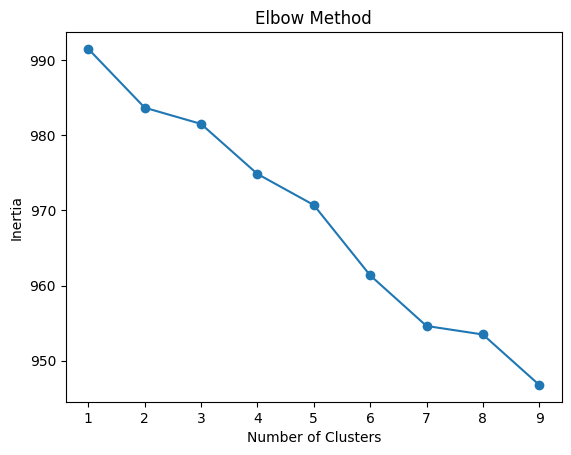

In [6]:
inertia = []

K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [7]:
k = 5  # choose based on elbow plot

kmeans = KMeans(n_clusters=k, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

In [8]:
terms = vectorizer.get_feature_names_out()

for i in range(k):
    center_terms = kmeans.cluster_centers_[i]
    top_terms = [terms[ind] for ind in center_terms.argsort()[-10:]]
    
    print(f"\nCluster {i}:")
    print(", ".join(top_terms))


Cluster 0:
antarctic, px, meteora, alpspitze, xpx, unknown, route, oc, large, climber

Cluster 1:
climbing, wall, hvs, stanage, bc, peak, district, uk, squamish, oc

Cluster 2:
xoc, indian, utah, tree, bouldering, creek, park, rock, climbing, photo

Cluster 3:
mind, trick, jedi, boulder, california, happy, xoc, buttermilk, bishop, ca

Cluster 4:
landjager, martini, moonshine, getting, roof, lobster, claw, tx, tank, hueco


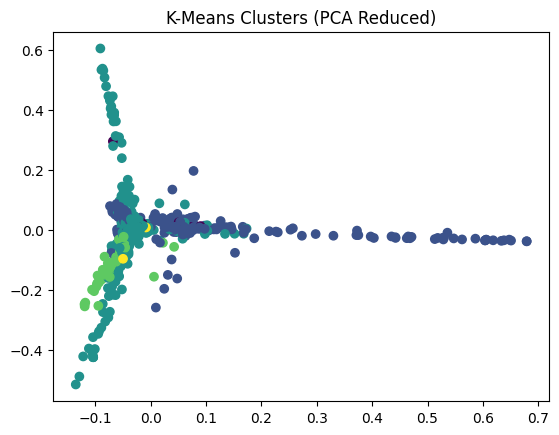

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'])
plt.title("K-Means Clusters (PCA Reduced)")
plt.show()

In [10]:
df.to_csv("ClimbingPorn_clustered.csv", index=False)